Data Loading & Cleaning

In [107]:
import mailbox
import pandas as pd
from email import message_from_string
from email.utils import parsedate_to_datetime

mbox = mailbox.mbox('All mail Including Spam and Trash.mbox')


def contains_photos(message):
    if message.is_multipart():
        for part in message.walk():
            content_type = part.get_content_type()
            if content_type.startswith("image"):  # Check if it's an image
                return True
    return False
def classify_email(subject, sender_email, recipient_email, headers):
    subject_lower = subject.lower()
    sender_email_lower = sender_email.lower()
    recipient_email_lower = recipient_email.lower()

    if sender_email_lower == recipient_email_lower:
        return "Itself"
    elif "trash" in subject_lower or "deleted" in subject_lower or "removed" in subject_lower or "X-Trash" in headers:
        return "Trash"
    elif "spam" in subject_lower or "free" in subject_lower or "win" in subject_lower:
        return "Spam"
    elif ".edu" in sender_email_lower or "university" in subject_lower or "exam" in subject_lower or "nptel" in sender_email_lower:
        return "University"
    elif "offer" in subject_lower or "sale" in subject_lower or "promotion" in subject_lower or "job alerts" in subject_lower:
        return "Commercial"
    elif "archive" in subject_lower or "archived" in subject_lower:
        return "Archived"
    else:
        return "Other"

def extract_email_content(message):
    if message.is_multipart():
        for part in message.walk():
            # Check for the plain text content
            if part.get_content_type() == 'text/plain':
                return part.get_payload(decode=True).decode(errors='replace')
    else:
        # Non-multipart emails
        return message.get_payload(decode=True).decode(errors='replace')
    return "No Content"

def classify_time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

emails = []

for message in mbox:
    email_message = message_from_string(message.as_string())
    subject = email_message['subject'] or "No Subject"
    sender = email_message['from'] or "No Sender"
    recipient = email_message['to'] or "No Recipient"
    date = email_message['date'] or "No Date"

    subject = subject.replace('\n', '').replace('\r', '')
    sender = sender.replace('\n', '').replace('\r', '')
    recipient = recipient.replace('\n', '').replace('\r', '')

    if "<" in sender and ">" in sender:
        sender_name = sender.split("<")[0].strip()
        sender_email = sender.split("<")[1].replace(">", "").strip()
    else:
        sender_name = sender
        sender_email = "Unknown"
    if "<" in recipient and ">" in recipient:
        recipient_email = recipient.split("<")[1].replace(">", "").strip()
    else:
        recipient_email = recipient
    content = extract_email_content(email_message)
    has_photos = "Yes" if contains_photos(email_message) else "No"
    category = classify_email(subject, sender_email, recipient_email, {})
    try:
        parsed_date = parsedate_to_datetime(date)
        email_date = parsed_date.date()
        email_time = parsed_date.time()
        day_of_week = parsed_date.strftime("%A")  # Full day name (e.g., Monday)
        is_weekend = "Weekend" if day_of_week in ["Saturday", "Sunday"] else "Weekday"
        time_of_day = classify_time_of_day(parsed_date.hour)
    except Exception:
        email_date = "Invalid Date"
        email_time = "Invalid Time"
        day_of_week = "Unknown"
        is_weekend = "Unknown"
        time_of_day = "Unknown"

    emails.append({

        'Sender Name': sender_name,
        'Sender Email': sender_email,
        'Recipient Email': recipient_email,
        'Subject': subject,
        'Date': email_date,
        'Time': email_time,
        'Day of Week': day_of_week,
        'Weekday/Weekend': is_weekend,
        'Time of Day': time_of_day,
        'Has Photos': has_photos,
        'Content': content,
         'Category': category,
    })

df = pd.DataFrame(emails)

df.head()

,Sender Name,Sender Email,Recipient Email,Subject,Date,Time,Day of Week,Weekday/Weekend,Time of Day,Has Photos,Content,Category
0,LeetCode,no-reply@leetcode.com,dhana172022@gmail.com,"7z3VwPJKzF, Join LeetCode Contest and get read...",2025-02-13,01:45:50,Thursday,Weekday,Night,No,No Content,Other
1,LinkedIn Job Alerts,jobalerts-noreply@linkedin.com,dhana172022@gmail.com,=?UTF-8?Q?22_new_jobs_for_=E2=80=9Cfull_stack_...,2025-02-12,17:32:58,Wednesday,Weekday,Evening,No,Your job alert for full stack engineer in Madu...,Other
2,POCEnglish,info@pocenglish.com,dhana172022@gmail.com,"Restart Your English Journey, Now Faster with AI!",2025-02-13,13:04:49,Thursday,Weekday,Afternoon,No,"Hello,\n\nYou have received a newsletter from ...",Other
3,NPTEL,onlinecourses@nptel.iitm.ac.in,exam-registration-reminder-jan25-set1-4-8@npte...,REMINDER: EXAM REGISTRATION FOR JANUARY 2025 -...,2025-02-11,18:24:42,Tuesday,Weekday,Evening,No,<https://examform.nptel.ac.in>\n\nThanks and R...,University
4,onlinecourses@cec2.swayam2.ac.in,Unknown,cec25-hs74-announce@cec2.swayam2.ac.in,ANNOUNCEMENT FOR SUBMISSION OF ASSESSMENT 2/QU...,2025-02-13,08:11:28,Thursday,Weekday,Morning,No,<div>Dear Learners</div><div><br></div><div>Al...,Other


<Axes: >

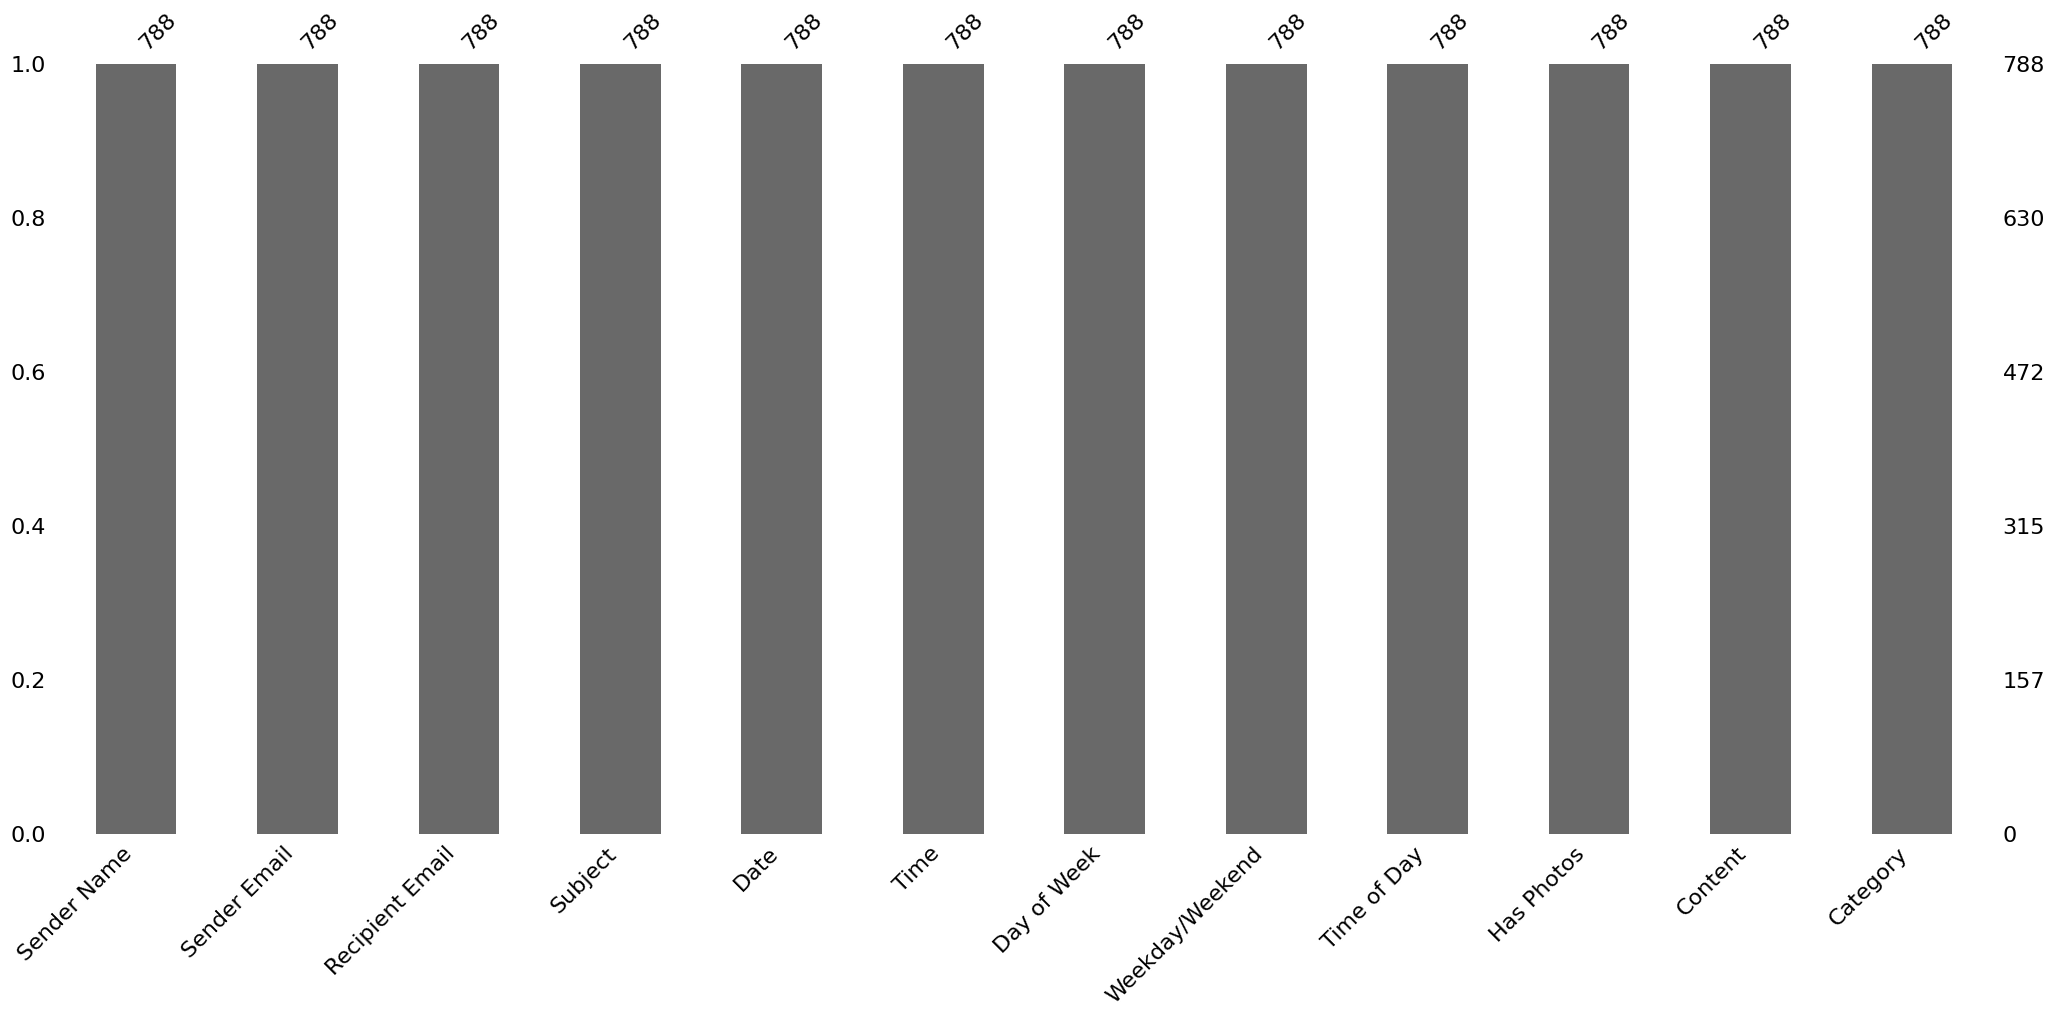

In [ ]:
import matplotlib.pyplot as plt
import missingno as mno
mno.bar(df)

there is no missing values


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time


2.EDA

In [ ]:

s=(df['Sender Email']=='dhana172022@gmail.com').sum()
r=(df['Recipient Email']=='dhana172022@gmail.com').sum()
print("number of mails sent : ",s)
print("number of mails received : ",r)


number of mails sent :  79
number of mails received :  722


In [ ]:
import seaborn as sns
df['Sender Email'].value_counts().head(10)

,count
Sender Email,
jobalerts-noreply@linkedin.com,192
dhana172022@gmail.com,79
noreply@medium.com,48
Coursera@m.learn.coursera.org,25
Unknown,24
updates@simplilearnmailer.com,21
messages-noreply@linkedin.com,20
info@pocenglish.com,17
updates-noreply@linkedin.com,16


In [ ]:
d1=df['Recipient Email'].groupby(df['Date']).size()
print('the average number of emails received per day : ',d1.mean())

the average number of emails received per day :  6.793103448275862


In [ ]:
edf = df[['Recipient Email', 'Date']].copy()  # Create a DataFrame with 'Recipient Email' and 'Date' columns
edf['ISO Week'] = edf['Date'].dt.isocalendar().week
w = edf.groupby('ISO Week').size()
print('the average number of emails received per week : ',w.mean())

the average number of emails received per week :  43.77777777777778


<ipython-input-66-a71bda5a6cbe>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Subject Length'])


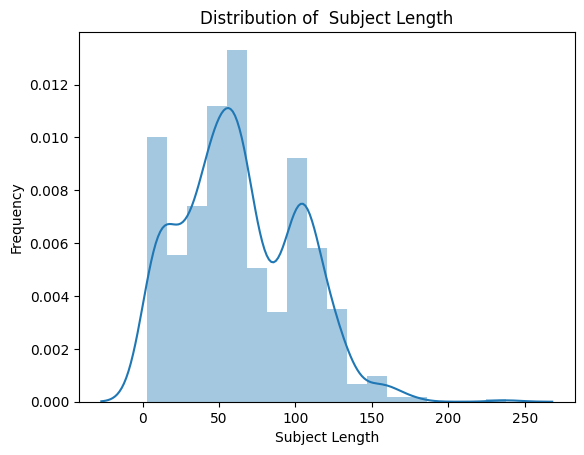

In [ ]:
df['Subject Length'] = df['Subject'].str.len()

sns.distplot(df['Subject Length'])
plt.title('Distribution of  Subject Length')
plt.xlabel('Subject Length')
plt.ylabel('Frequency')
plt.show()


3.visualization Tasks

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'LinkedIn Job Alerts'),
  Text(1, 0, 'Dhanalakshmi A'),
  Text(2, 0, 'LinkedIn'),
  Text(3, 0, 'Medium Daily Digest'),
  Text(4, 0, '"Coding Ninjas"'),
  Text(5, 0, '"Coursera"'),
  Text(6, 0, '"Simplilearn"'),
  Text(7, 0, 'POCEnglish'),
  Text(8, 0, '"=?utf-8?B?QVNVUyBJbmRpYQ==?="'),
  Text(9, 0, 'onlinecourses@nptel.iitm.ac.in')])

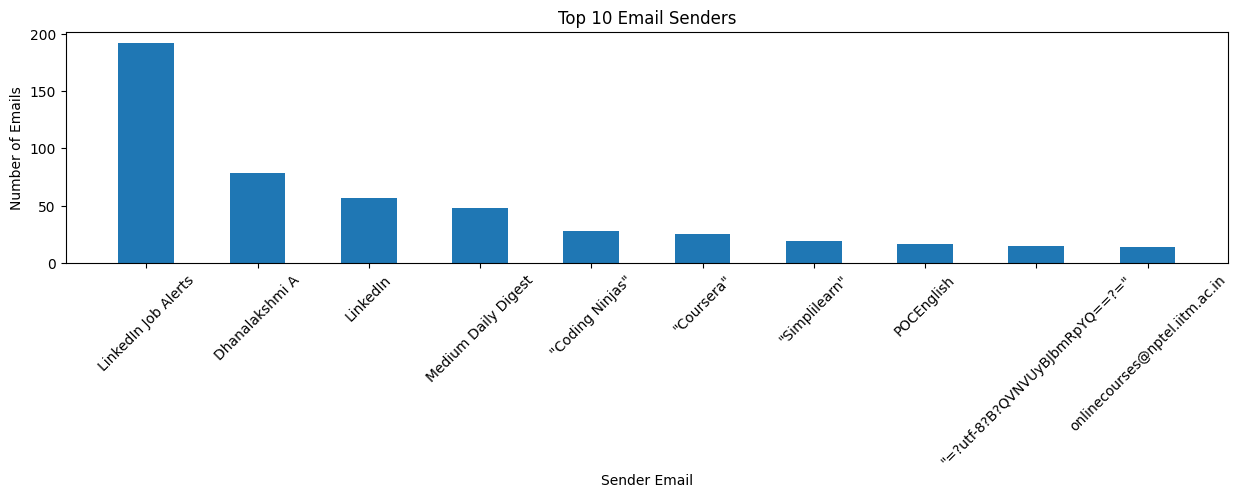

In [ ]:
top=df['Sender Name'].value_counts().head(10)
plt.figure(figsize=(15,3))
plt.bar(top.index,top.values, width=0.5)
plt.xlabel('Sender Email')
plt.ylabel('Number of Emails')
plt.title('Top 10 Email Senders')
plt.xticks(rotation=45)

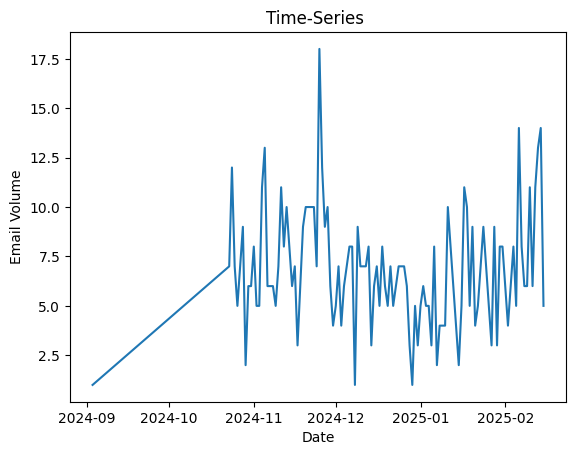

In [ ]:
t = df.groupby('Date').size()

plt.plot(t.index, t.values)
plt.xlabel('Date')
plt.ylabel('Email Volume')
plt.title('Time-Series ')
plt.show()


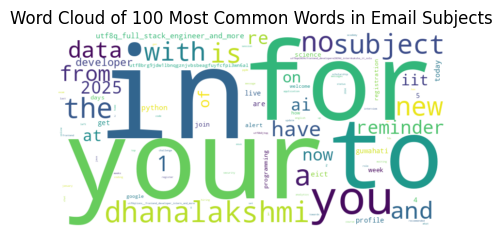

In [ ]:
from collections import Counter
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
text = " ".join(subject for subject in df.Subject)
words = text.lower().split()

words = [re.sub(r'[^\w\s]', '', word) for word in words]
words = [word for word in words if word]
w = Counter(words)
w = w.most_common(100)
wor = WordCloud(width=800, height=400, background_color="white", stopwords=STOPWORDS).generate_from_frequencies(dict(most_common_words))
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(f"Word Cloud of {N} Most Common Words in Email Subjects")
plt.show()

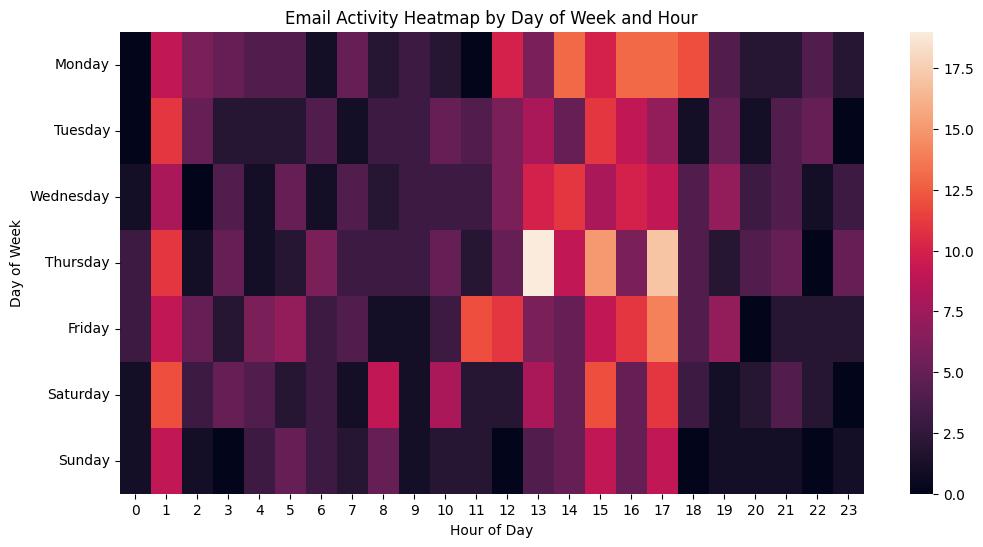

In [ ]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.time
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

email_activity = df.pivot_table(index='Day of Week', columns='Hour', values='Subject', aggfunc='count', fill_value=0)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
email_activity = email_activity.reindex(days_order)
plt.figure(figsize=(12, 6))
sns.heatmap(email_activity)
plt.title('Email Activity Heatmap by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()


The analysis of the email dataset reveals several key patterns:

1. **Communication Frequency:**  The code calculates and visualizes the number of emails sent and received by the main user, along with average emails received per day and per week.  This provides insights into overall communication volume and trends over time.

2. **Top Senders:** Identification of the top 10 email senders highlights frequent correspondents and potential key relationships.

3. **Email Traffic Trends:** A time-series plot of email volume over time reveals patterns in communication frequency, including potential peaks or troughs, suggesting periods of increased or decreased activity.

4. **Subject Line Analysis:** Examination of subject line lengths and the most common words in subject lines offers insights into communication topics and potential themes.  A word cloud visualization emphasizes prevalent keywords.

5. **Temporal Patterns:**  Analysis of email activity by day of the week and hour provides insights into daily and weekly usage patterns.  A heatmap visualizes these patterns, indicating periods of high and low email activity.

6. **Email Categorization:** A custom function categorizes emails (e.g., spam, university-related, commercial) which allows for further analysis of different communication types.

7. **Photo Attachments:**  Detection of emails containing images provides information on multimedia communication trends.

8. **Data Quality:** Initial checks identified no missing values in the dataset.

In summary, the analysis combines descriptive statistics, visualizations, and custom classification to reveal patterns in email communication volume, sender activity, subject matter, and temporal trends.  These observations can be used to understand communication habits and identify key relationships.


**possible insights**


**1. Time Management and Productivity:**
   - Identify peak email activity times:  The heatmap showing email activity by day and hour reveals when email communication is most frequent.  This can inform scheduling of focused work blocks during periods of lower email traffic.  
    - Analyze weekend vs. weekday email behavior: Determine if the user responds to emails outside of work hours and consider if this behavior impacts work-life balance or productivity.  Perhaps set stricter boundaries for email response during non-work hours.
   - Analyze response times: Calculate the average response time to emails from various senders or email categories (e.g., clients, colleagues).  Identify delays or unusually long response times that may indicate potential bottlenecks or areas where responsiveness could improve.

**2. Communication Patterns and Prioritization:**
    - Prioritize communication with top senders: The top 10 senders list helps identify frequent correspondents, which could help in prioritizing communication. If specific senders frequently send urgent messages, consider setting up custom notifications.
    - Analyze the content of common subject lines: The word cloud and most frequent words in subjects reveal prevalent topics of discussion.  This can help in identifying recurring themes and potential areas for improvement in communication.
   - Categorize email types: The existing categorization (Spam, University, Commercial, etc.) allows for analysis of different email types. Analyze the volume of each category, and assess the amount of time spent on each one. This may reveal a need for better filtering or delegation.

**3.Relationship Management:**
   - Identify key relationships: The top senders provide insight into key relationships. Analyze the communication frequency and topic with these individuals.

**4.Spam and Unsubscriptions:**
   - Analyze the "Spam" and "Commercial" email categories to identify recurring senders and consider unsubscribing from unwanted mailing lists to reduce email clutter.

**5.  Additional Analysis:**
    - Analyze email length: Identify patterns in message length (long emails vs. short emails) and correlate them with time of day or sender.
    - Content analysis: Further analysis of email content could reveal additional insights into language used, topics of discussion and sentiment. -->
